In [58]:
import os

dt_size = os.path.getsize("D:/imu-har-exoskeleton-ai/models/decision_tree.pkl") / 1024
rf_size = os.path.getsize("D:/imu-har-exoskeleton-ai/models/random_forest.pkl") / 1024
xgb_size = os.path.getsize("D:/imu-har-exoskeleton-ai/models/xgboost.pkl") / 1024

print(f"Decision Tree: {dt_size:.2f} KB")
print(f"Random Forest: {rf_size:.2f} KB")
print(f"XGBoost: {xgb_size:.2f} KB")


Decision Tree: 53.31 KB
Random Forest: 5049.32 KB
XGBoost: 960.64 KB


In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [60]:
# Load feature dataset
X_train = pd.read_csv(
    "../data/UCI HAR Dataset/UCI HAR Dataset/train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    "../data/UCI HAR Dataset/UCI HAR Dataset/train/y_train.txt",
    header=None
)

In [61]:
# Recreate validation split
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train.iloc[:, 0])

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [62]:
sample = X_val.iloc[[0]]

In [63]:
import time
import numpy as np
import joblib

dt = joblib.load("D:/imu-har-exoskeleton-ai/models/decision_tree.pkl")
rf = joblib.load("D:/imu-har-exoskeleton-ai/models/random_forest.pkl")
xgb = joblib.load("D:/imu-har-exoskeleton-ai/models/xgboost.pkl")

sample = X_val.iloc[[0]]

X_train.columns = feature_names[1]

In [64]:
start = time.perf_counter()

for _ in range(1000):
    dt.predict(sample)

end = time.perf_counter()

dt_time = (end - start) / 1000

print("DT:", dt_time)

d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fit

DT: 0.00456030969999847


d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fit

In [65]:
start = time.perf_counter()

for _ in range(1000):
    rf.predict(sample)

end = time.perf_counter()

rf_time = (end - start) / 1000

print("RF:", rf_time)

d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

RF: 0.010644227500015403


In [66]:
sample_np = sample.values

start = time.perf_counter()

for _ in range(1000):
    xgb.predict(sample_np)

end = time.perf_counter()

xgb_time = (end - start) / 1000

print("XGB:", xgb_time)

XGB: 0.0006446771999762859


In [67]:
import pandas as pd

deployment_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy (%)": [93.68, 98.16, 99.12],
    "Model Size (KB)": [dt_size, rf_size, xgb_size],
    "Prediction Time (ms)": [
        dt_time * 1000,
        rf_time * 1000,
        xgb_time * 1000
    ]
})

deployment_df

,Model,Accuracy (%),Model Size (KB),Prediction Time (ms)
0,Decision Tree,93.68,53.305664,4.560310
1,Random Forest,98.16,5049.321289,10.644228
2,XGBoost,99.12,960.641602,0.644677


In [68]:
feature_names = pd.read_csv(
    "../data/UCI HAR Dataset/UCI HAR Dataset/features.txt",
    sep=r"\s+",
    header=None
)

feature_names.head()

,0,1
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y


In [69]:
feature_names[1].head(20)

0       tBodyAcc-mean()-X
1       tBodyAcc-mean()-Y
2       tBodyAcc-mean()-Z
3        tBodyAcc-std()-X
4        tBodyAcc-std()-Y
5        tBodyAcc-std()-Z
6        tBodyAcc-mad()-X
7        tBodyAcc-mad()-Y
8        tBodyAcc-mad()-Z
9        tBodyAcc-max()-X
10       tBodyAcc-max()-Y
11       tBodyAcc-max()-Z
12       tBodyAcc-min()-X
13       tBodyAcc-min()-Y
14       tBodyAcc-min()-Z
15         tBodyAcc-sma()
16    tBodyAcc-energy()-X
17    tBodyAcc-energy()-Y
18    tBodyAcc-energy()-Z
19       tBodyAcc-iqr()-X
Name: 1, dtype: str

In [70]:
acc_features = [
    col for col in X_train.columns
    if (
        "BodyAcc" in col
        or "GravityAcc" in col
        or "BodyAccJerk" in col
        or "BodyAccMag" in col
    )
]

In [71]:
gyro_features = [
    col for col in X_train.columns
    if (
        "BodyGyro" in col
        or "BodyGyroJerk" in col
    )
]

In [72]:
print("Accelerometer Features:", len(acc_features))
print("Gyroscope Features:", len(gyro_features))
print("Total Features:", X_train.shape[1])

Accelerometer Features: 345
Gyroscope Features: 213
Total Features: 561


In [73]:
X_acc = X_train[acc_features]

X_gyro = X_train[gyro_features]

X_combined = X_train

In [74]:
X_acc_train, X_acc_val, y_acc_train, y_acc_val = train_test_split(
    X_acc,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_gyro_train, X_gyro_val, y_gyro_train, y_gyro_val = train_test_split(
    X_gyro,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_comb_train, X_comb_val, y_comb_train, y_comb_val = train_test_split(
    X_combined,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [75]:
print("Accelerometer Features:", len(acc_features))
print("Gyroscope Features:", len(gyro_features))
print("Total Features:", X_train.shape[1])

Accelerometer Features: 345
Gyroscope Features: 213
Total Features: 561


In [76]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_acc = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_acc.fit(X_acc_train.values, y_acc_train)

acc_pred = xgb_acc.predict(X_acc_val.values)

acc_accuracy = accuracy_score(
    y_acc_val,
    acc_pred
)

print("Accelerometer Accuracy:", acc_accuracy)

Accelerometer Accuracy: 0.9898028552005439


In [77]:
xgb_gyro = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_gyro.fit(X_gyro_train.values, y_gyro_train)

gyro_pred = xgb_gyro.predict(X_gyro_val.values)

gyro_accuracy = accuracy_score(
    y_gyro_val,
    gyro_pred
)

print("Gyroscope Accuracy:", gyro_accuracy)

Gyroscope Accuracy: 0.9306594153636981


In [78]:
xgb_comb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_comb.fit(X_comb_train.values, y_comb_train)

comb_pred = xgb_comb.predict(X_comb_val.values)

comb_accuracy = accuracy_score(
    y_comb_val,
    comb_pred
)

print("Combined Accuracy:", comb_accuracy)

Combined Accuracy: 0.991162474507138


In [79]:
import pandas as pd

ablation_df = pd.DataFrame({
    "Sensor Type": [
        "Accelerometer",
        "Gyroscope",
        "Combined"
    ],
    "Accuracy": [
        acc_accuracy,
        gyro_accuracy,
        comb_accuracy
    ]
})

ablation_df

,Sensor Type,Accuracy
0,Accelerometer,0.989803
1,Gyroscope,0.930659
2,Combined,0.991162


In [82]:
import pandas as pd
import joblib

xgb_model = joblib.load(
    "D:/imu-har-exoskeleton-ai/models/xgboost.pkl"
)

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

top20 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

top20

,Feature,Importance
330,"fBodyAcc-bandsEnergy()-1,8",0.067192
52,tGravityAcc-min()-X,0.066113
504,fBodyAccMag-mad(),0.047965
166,tBodyGyroJerk-mad()-X,0.044905
518,fBodyBodyAccJerkMag-max(),0.039993
296,fBodyAcc-skewness()-X,0.028435
503,fBodyAccMag-std(),0.028091
559,"angle(Y,gravityMean)",0.027821
9,tBodyAcc-max()-X,0.025699
90,tBodyAccJerk-max()-Y,0.024868


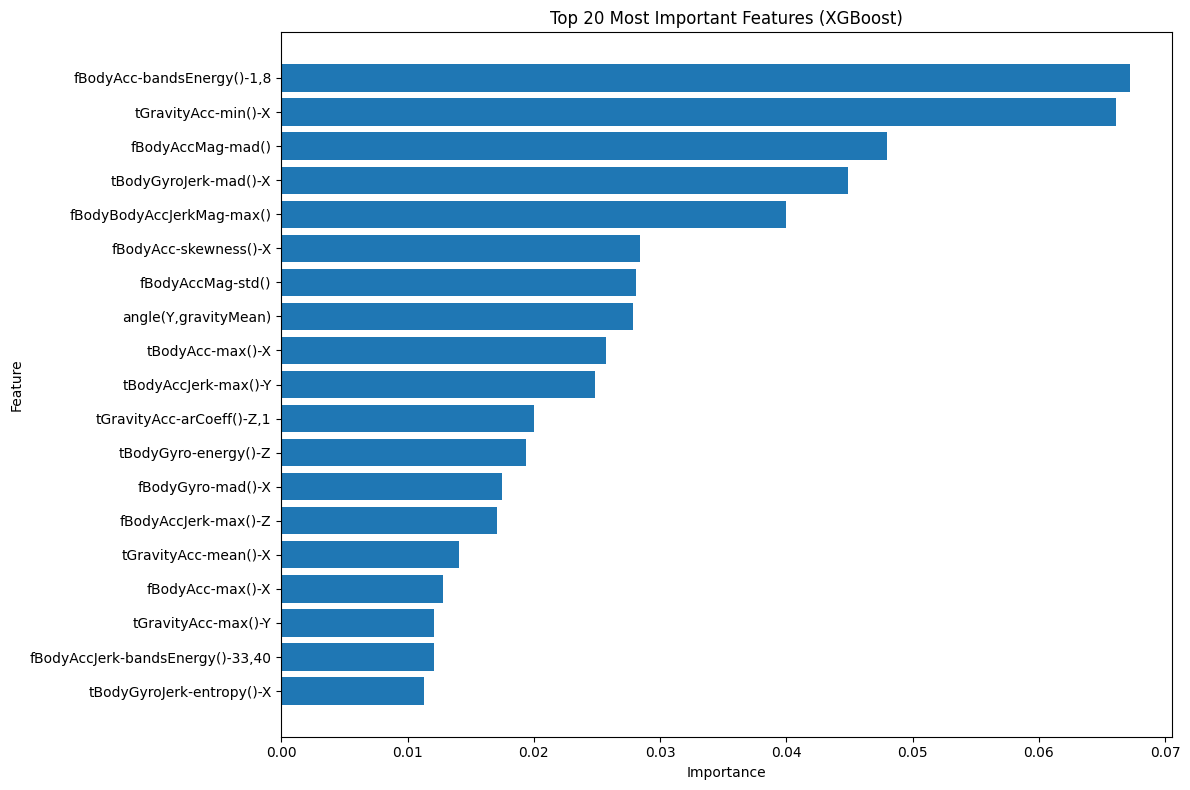

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 20 Most Important Features (XGBoost)")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../results/top20_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()